# Healthcare Readmission Prediction

### Understand the REAL Business Problem

#### What is “Hospital Readmission”?

Readmission means:

A patient gets discharged from hospital…

BUT comes back again within a short period (usually 30 days).

Example:

Patient treated for diabetes

Goes home

Condition worsens

Comes back again after 10 days

That is called:

Hospital Readmission

# What Are WE Trying to Solve?

Hospitals want to predict:

“Which diabetic patients are likely to come back within 30 days?”

Why?

Because:

Readmissions cost money

Hospitals may get penalties

Patient health suffers

Hospital beds get occupied


This becomes a:

## Binary Classification Problem

Because output is:

Output	Meaning
1	Patient likely to return
0	Patient unlikely to return

## import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [ ]:
df = pd.read_csv(r'health logstic diabetic_data.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
df.shape

(101766, 50)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

we see that there are many missing values but in the form of "?" w have to replace it with NaN 

In [5]:
df.replace('?', np.nan, inplace=True)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


now we replce ? with NaN , numpy easly detect the missing values using isnull function this help to find the null/ issing value in datasets

# AGE vs READMISSION (Countplot)

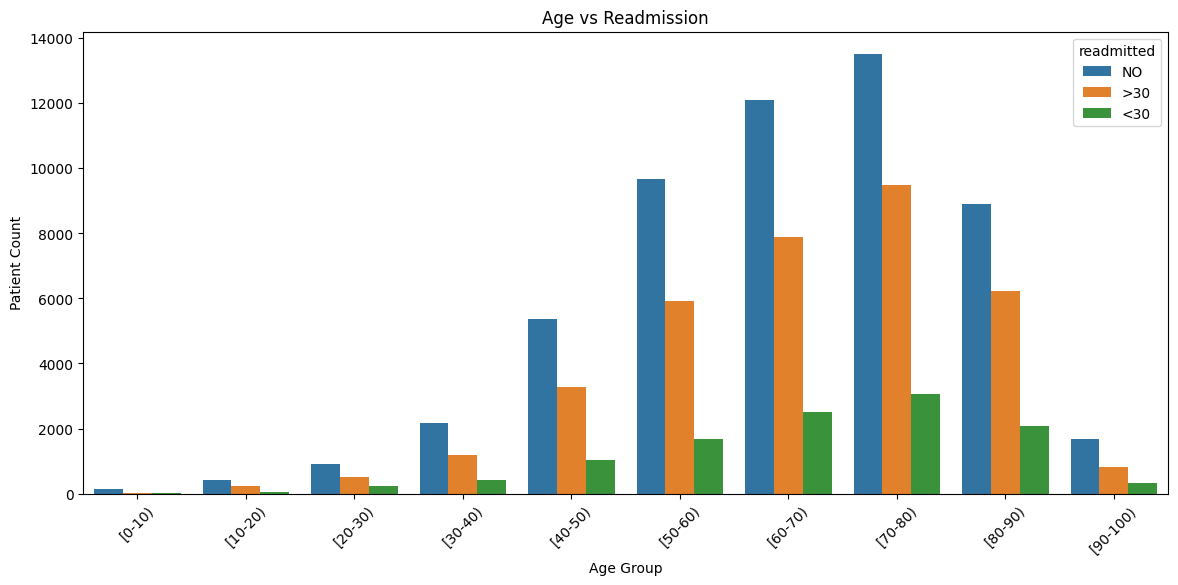

In [6]:
plt.figure(figsize=(14,6))

sns.countplot(
    data=df,
    x='age',
    hue='readmitted'
)

plt.title('Age vs Readmission')
plt.xlabel('Age Group')
plt.ylabel('Patient Count')
plt.xticks(rotation=45)

plt.show()

Older age groups show higher readmission frequency.

# INSULIN vs READMISSION (Countplot)

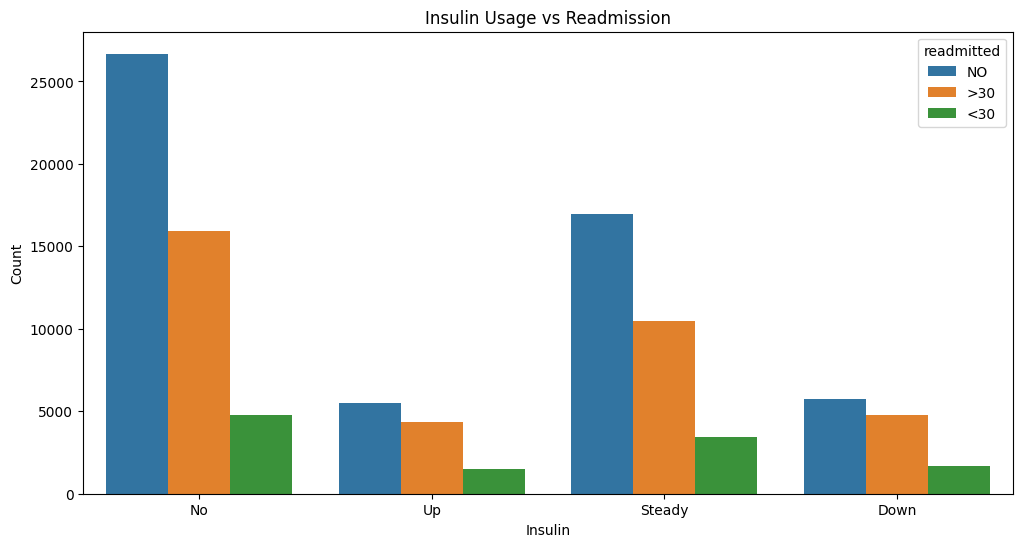

In [7]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='insulin',
    hue='readmitted'
)

plt.title('Insulin Usage vs Readmission')
plt.xlabel('Insulin')
plt.ylabel('Count')

plt.show()

Patients with changing insulin usage patterns may show different readmission trends.

# TIME_IN_HOSPITAL vs READMISSION (Boxplot)

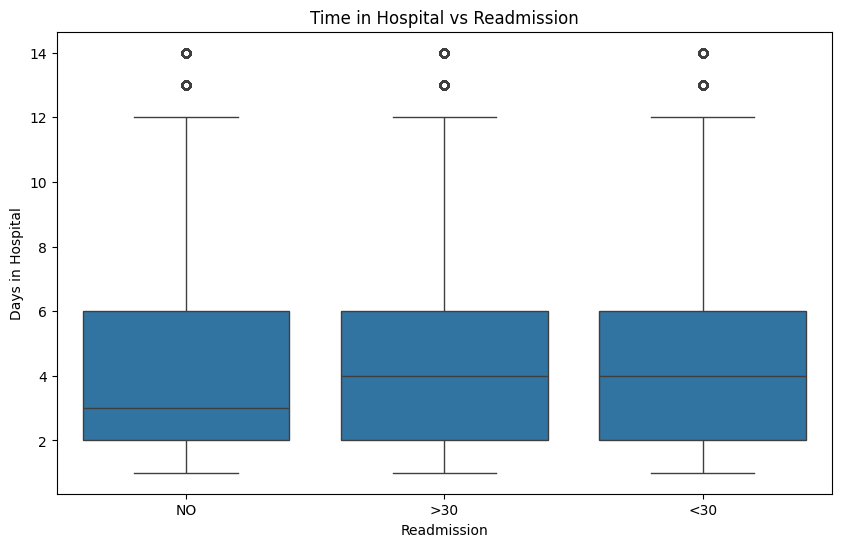

In [8]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='readmitted',
    y='time_in_hospital'
)

plt.title('Time in Hospital vs Readmission')
plt.xlabel('Readmission')
plt.ylabel('Days in Hospital')

plt.show()

Patients staying longer in hospitals tend to have higher readmission risk.

# NUMBER OF MEDICATIONS vs READMISSION (Boxplot)

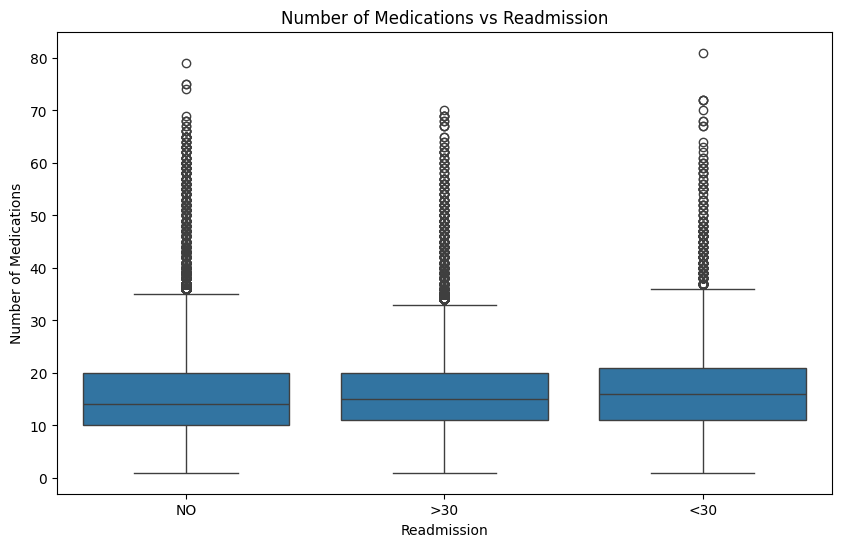

In [9]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='readmitted',
    y='num_medications'
)

plt.title('Number of Medications vs Readmission')
plt.xlabel('Readmission')
plt.ylabel('Number of Medications')

plt.show()

Higher medication count may indicate severe conditions linked to readmission.

# HEATMAP (Correlation Analysis)

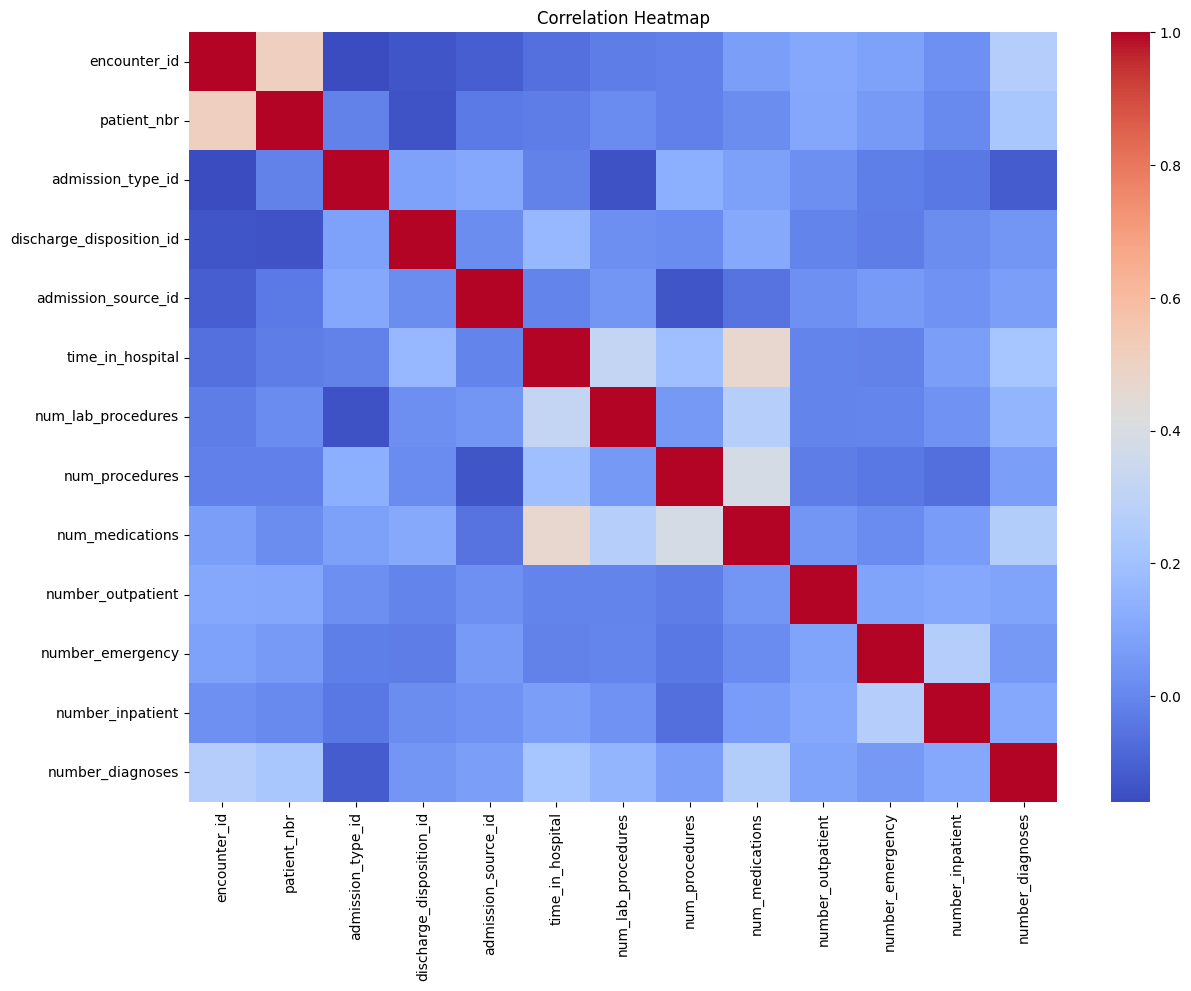

In [10]:
plt.figure(figsize=(14,10))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title('Correlation Heatmap')

plt.show()

In [11]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

Now we know thyat which columns has missing value so we drop the unnecessory and high missing value columns

In [12]:
df.drop(['weight', 'payer_code','encounter_id', 'patient_nbr'], axis=1, inplace=True)

You have notic that medical_specialty also have missing values but why can we drop it its because medical_specialtymay have some important information and we drop only that column that are irrelevent for us or unnecesserey for us. medical_specialty is important for us so we fill it here we have two options to fill it First you have to understand its a categorical column so we have two option 1 is Mode and 2 is unknown

Mode when we have few missing values

Unknown when we have many missing values

In [13]:
df['medical_specialty'].fillna("unknown", inplace = True)

C:\Users\rajpu\AppData\Local\Temp\ipykernel_8476\4199359725.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['medical_specialty'].fillna("unknown", inplace = True)


0         Pediatrics-Endocrinology
1                          unknown
2                          unknown
3                          unknown
4                          unknown
                    ...           
101761                     unknown
101762                     unknown
101763                     unknown
101764             Surgery-General
101765                     unknown
Name: medical_specialty, Length: 101766, dtype: str

In [14]:
df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

As we know that we trying to solve the binarycproblem  so we have to covert it into 0 1 form 

In [15]:
df['readmitted'] = df['readmitted'].replace({
    '<30': 1,
    '>30': 0,
    'NO': 0
})

In [16]:
df['readmitted'].value_counts()

readmitted
0    90409
1    11357
Name: count, dtype: int64

Now we have data in 0 1 form
 
1 = Readmitted

0 = Not Readmitted

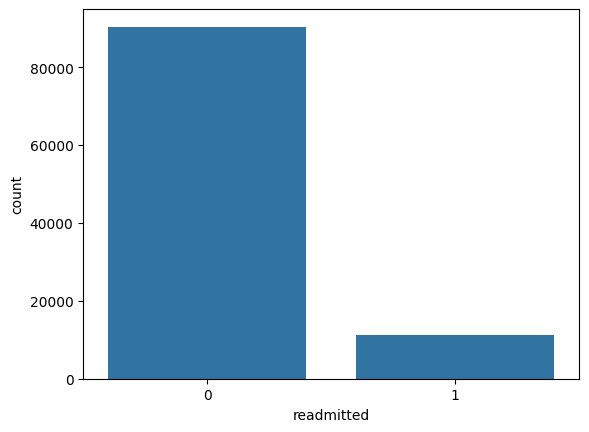

In [17]:
sns.countplot(x='readmitted', data=df)

plt.show()

In [18]:
df.dtypes

race                           str
gender                         str
age                            str
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
medical_specialty              str
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                         str
diag_2                         str
diag_3                         str
number_diagnoses             int64
max_glu_serum                  str
A1Cresult                      str
metformin                      str
repaglinide                    str
nateglinide                    str
chlorpropamide                 str
glimepiride                    str
acetohexamide                  str
glipizide                      str
glyburide                      str
tolbutamide         

In [19]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

C:\Users\rajpu\AppData\Local\Temp\ipykernel_8476\910776789.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


Index(['race', 'gender', 'age', 'medical_specialty', 'diag_1', 'diag_2',
       'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
       'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
       'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
       'glipizide-metformin', 'glimepiride-pioglitazone',
       'metformin-rosiglitazone', 'metformin-pioglitazone', 'change',
       'diabetesMed', 'readmitted'],
      dtype='str')

As we know that Logestic regression need numerical column that means int or float but we see that e have many columne that type is obje so we need to conver it ointo int and float manner so that oput model work properly 

you might wonedr why now we use simple way to conver datatype like df['age'] = df['age'].astype(str), it because it can convert or encode txt.Text remain tesxt and also it take too much time so we use encoading 

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 46 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   race                      101766 non-null  int64
 1   gender                    101766 non-null  int64
 2   age                       101766 non-null  int64
 3   admission_type_id         101766 non-null  int64
 4   discharge_disposition_id  101766 non-null  int64
 5   admission_source_id       101766 non-null  int64
 6   time_in_hospital          101766 non-null  int64
 7   medical_specialty         101766 non-null  int64
 8   num_lab_procedures        101766 non-null  int64
 9   num_procedures            101766 non-null  int64
 10  num_medications           101766 non-null  int64
 11  number_outpatient         101766 non-null  int64
 12  number_emergency          101766 non-null  int64
 13  number_inpatient          101766 non-null  int64
 14  diag_1                    10176

Now we have all the columns in numerical for lets define our x and y (featurs and Target)

In [22]:
X = df.drop('readmitted', axis=1)

y = df['readmitted']

## Train and Test Split

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

80% trainng and 20% testing

Now we have to scale our data because Logestic regression work better with scaling this helps to make all features to a similar range

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Train Logestic regression

In [25]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# Make prediction

In [26]:
y_pred = model.predict(X_test)

In [27]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

check the accuracy of our model

In [28]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8871966198290262


In [29]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[18032    37]
 [ 2259    26]]


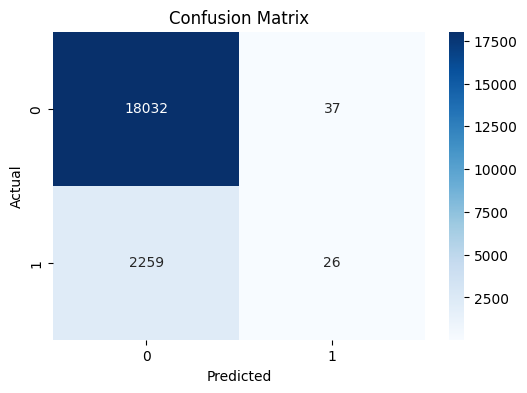

In [30]:
plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18069
           1       0.41      0.01      0.02      2285

    accuracy                           0.89     20354
   macro avg       0.65      0.50      0.48     20354
weighted avg       0.84      0.89      0.84     20354



In [32]:
y_prob = model.predict_proba(X_test)[:,1]

roc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.643375109733137


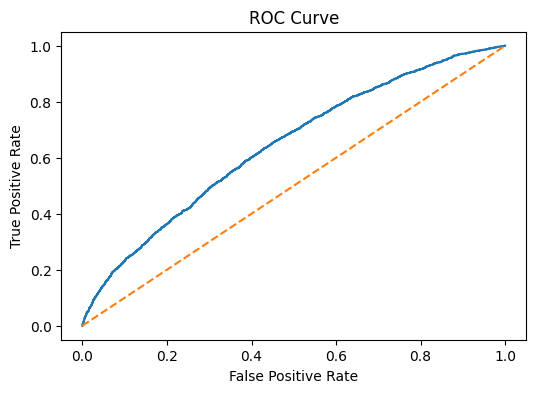

In [33]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()